# DL083 语言模型适配与参数高效微调

本Notebook使用真实Python内核顺序运行。先读lecture.md与lab.md。只验证明确限定的离线教学机制，不代表真实LLM性能。

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import experiment as exp
print("Python",sys.version.split()[0],"NumPy",np.__version__)

Python 3.12.14 NumPy 2.3.5


## 完整实验与真实输出
运行会在本目录outputs写入可复核结果。

In [2]:
result=exp.main()
print(json.dumps(result,ensure_ascii=False,indent=2))

{
  "seed": 83,
  "model": "single-step conditional softmax; not a Transformer or pretrained LLM",
  "train_rows": 240,
  "adaptation_test_rows": 120,
  "retention_rows": 360,
  "results": {
    "frozen": {
      "adaptation_test": {
        "nll": 1.967390899396422,
        "accuracy": 0.25
      },
      "retention_test": {
        "nll": 1.662891943161282,
        "accuracy": 0.3888888888888889
      },
      "train_nll": 2.102634762163676,
      "trainable_parameters": 0,
      "trainable_float64_bytes": 0,
      "observed_cpu_seconds": 0.0008924549983930774,
      "delta_rank": 0,
      "merge_max_abs_error": 0
    },
    "full": {
      "adaptation_test": {
        "nll": 1.4567366953123222,
        "accuracy": 0.48333333333333334
      },
      "retention_test": {
        "nll": 3.281118815573175,
        "accuracy": 0.26666666666666666
      },
      "train_nll": 0.9646055581134941,
      "trainable_parameters": 96,
      "trainable_float64_bytes": 768,
      "observed_cpu_seco

## 形状与数据边界

In [3]:
X,y,Xt,yt,Xr,yr,W0 = exp.fixture()
print([a.shape for a in [X,y,Xt,yt,Xr,yr,W0]])

[(240, 12), (240,), (120, 12), (120,), (360, 12), (360,), (8, 12)]


## 掩码等价

In [4]:
mask=np.zeros(len(y));mask[:7]=1
a=exp.loss_grad(X,y,W0,mask)[0]
b=exp.loss_grad(X[:7],y[:7],W0)[0]
print(a,b)
np.testing.assert_allclose(a,b)

2.2540872344754748 2.2540872344754748


## 低秩与合并

In [5]:
W,h,A,B=exp.train(X,y,W0,"lora",2)
print("delta rank",np.linalg.matrix_rank(W-W0,tol=1e-8))
print("trainable parameters",A.size+B.size)
np.testing.assert_allclose(Xt@W.T,Xt@W0.T+(Xt@A.T)@B.T,atol=1e-12)

delta rank 2
trainable parameters 40


## 全部单元测试
同时检查边界与失败路径，不只观察损失下降。

In [6]:
import unittest
suite=unittest.defaultTestLoader.discover(str(Path.cwd()),pattern="test_experiment.py")
check=unittest.TextTestRunner(verbosity=2).run(suite)
if not check.wasSuccessful(): raise RuntimeError("tests failed")

test_disjoint (test_experiment.Tests.test_disjoint) ... 

ok


test_frozen (test_experiment.Tests.test_frozen) ... 

ok


test_full_decreases (test_experiment.Tests.test_full_decreases) ... 

...

test_softmax_rows (test_experiment.Tests.test_softmax_rows) ... 

ok


test_softmax_shift (test_experiment.Tests.test_softmax_shift) ... 

ok


----------------------------------------------------------------------
Ran 13 tests in 0.330s

OK


## 从输出重建原创图
图的数值来自本次实验，不是示意数字。

figure count 3


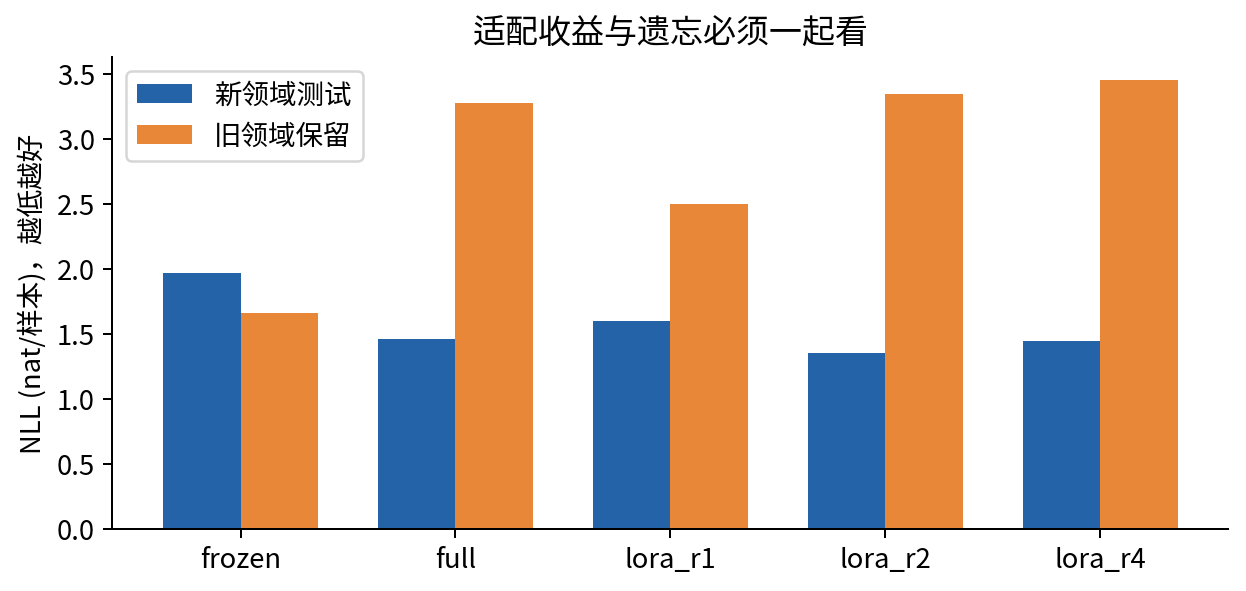

In [7]:
import make_figures
make_figures.main()
from IPython.display import display, Image
figures=sorted(Path("figures").glob("*.png"))
print("figure count",len(figures))
display(Image(filename=str(figures[-1])))

## 研究记录
写下一个受支持结论、一个失败/限制，以及下一步需要的新证据。参考答案在answers.md，不能用参考结论替代你自己的检查。

In [8]:
print("Output files:",sorted(p.name for p in Path("outputs").iterdir() if p.is_file()))

Output files: ['environment.json', 'history.json', 'metrics.json', 'notebook-execution.json', 'replay-comparison.json', 'weights.npz']
